# Lab4 - Evaluation and Visualization

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

We will explore evaluation and visualization techniques that can be applied to active learning methods. We are going to visualize:

- performance of active learning loop
- active learning KPI computation
- samples

## 0. Import libraries

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## 1. Data preparation

In [26]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('mnist_784', return_X_y=False)
X = bunch.data.to_numpy()
y = bunch.target.to_numpy()

### Get familiar with the dataset

In [27]:
from IPython.display import display, Markdown

display(Markdown(bunch.DESCR))

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image by computing the center of mass of the pixels, and translating the image so as to position this point at the center of the 28x28 field.  

With some classification methods (particularly template-based methods, such as SVM and K-nearest neighbors), the error rate improves when the digits are centered by bounding box rather than center of mass. If you do this kind of pre-processing, you should report it in your publications. The MNIST database was constructed from NIST's NIST originally designated SD-3 as their training set and SD-1 as their test set. However, SD-3 is much cleaner and easier to recognize than SD-1. The reason for this can be found on the fact that SD-3 was collected among Census Bureau employees, while SD-1 was collected among high-school students. Drawing sensible conclusions from learning experiments requires that the result be independent of the choice of training set and test among the complete set of samples. Therefore it was necessary to build a new database by mixing NIST's datasets.  

The MNIST training set is composed of 30,000 patterns from SD-3 and 30,000 patterns from SD-1. Our test set was composed of 5,000 patterns from SD-3 and 5,000 patterns from SD-1. The 60,000 pattern training set contained examples from approximately 250 writers. We made sure that the sets of writers of the training set and test set were disjoint. SD-1 contains 58,527 digit images written by 500 different writers. In contrast to SD-3, where blocks of data from each writer appeared in sequence, the data in SD-1 is scrambled. Writer identities for SD-1 is available and we used this information to unscramble the writers. We then split SD-1 in two: characters written by the first 250 writers went into our new training set. The remaining 250 writers were placed in our test set. Thus we had two sets with nearly 30,000 examples each. The new training set was completed with enough examples from SD-3, starting at pattern # 0, to make a full set of 60,000 training patterns. Similarly, the new test set was completed with SD-3 examples starting at pattern # 35,000 to make a full set with 60,000 test patterns. Only a subset of 10,000 test images (5,000 from SD-1 and 5,000 from SD-3) is available on this site. The full 60,000 sample training set is available.

Downloaded from openml.org.

In [28]:
print(bunch["url"])

https://www.openml.org/d/554


In [29]:
bunch.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB


### Target distribution

Use bar/histogram-like representation of target distribution.

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
[6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]
Total number of images: 70000


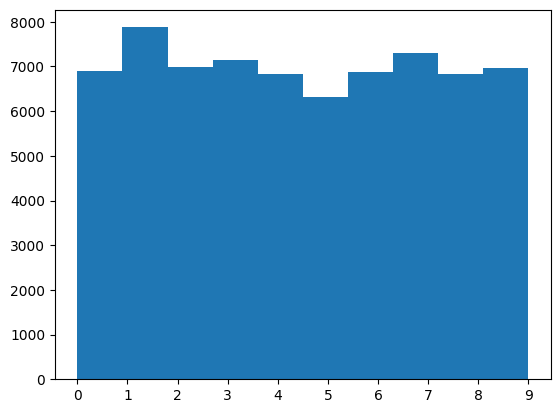

In [30]:
# write your code here
targets, counts = np.unique(y, return_counts=True)
print(targets)
print(counts)
print(f"Total number of images: {X.shape[0]}")

plt.hist(np.sort(y), bins=targets.size)
plt.show()


### Investigate how the images look like

Implement a function that can display a single image from the dataset. Let the function take also an optional argument that, if provided, will display the actual class name as the title of image.

Use the function to visualize a few images.

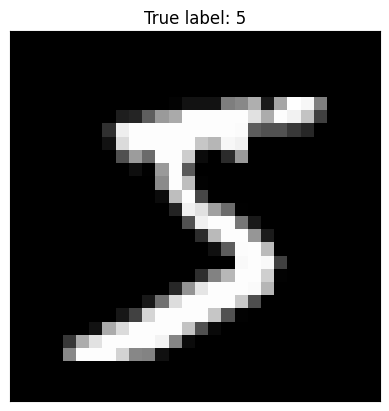

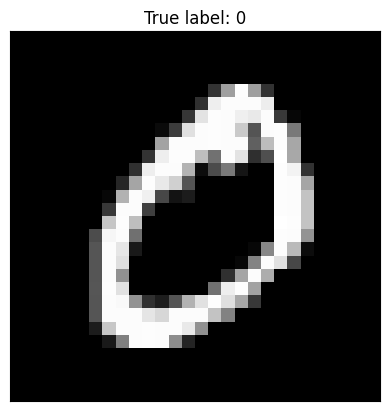

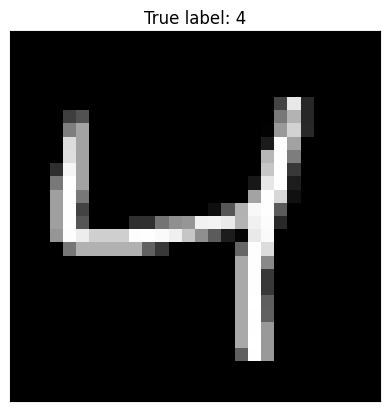

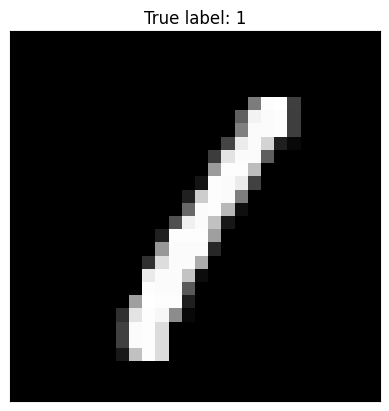

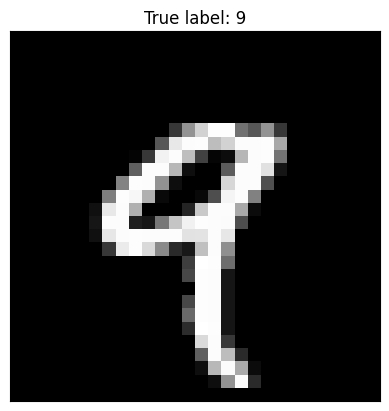

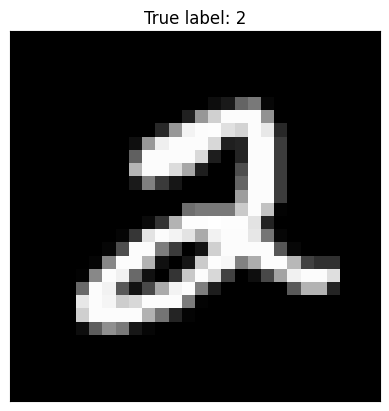

In [31]:
# write your code here

def display(image_number, show_label=False):
    image = X[image_number]
    image = image.reshape(int(np.sqrt(image.size)), int(np.sqrt(image.size)))

    plt.imshow(image, cmap="grey")
    plt.xticks(())
    plt.yticks(())
    plt.tick_params(axis="both", bottom=False, left=False)
    if show_label:
        plt.title(f"True label: {y[image_number]}")
    plt.show()\
    
for i in range(6):
    display(i, True)

### Prepare pool and eval data

Split the dataset into pool and eval subsets (with 60-40 ratio).

In [32]:
# write your code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y)



## 2. Prepare active learning framework

Adjust the active learning loop from the previous lab session so that you could perform experiments with different hyperparameters and machine learning models. After each iteration you should assess the model on the evaluation dataset using a given performance measure.

You should be able to:

- specify the initial batch selection strategy - random sample by default
- specify the initial batch size
- specify the number of active learning iterations
- specify the batch selection strategy - by default select samples having the largest informativeness value 
- specify the informativeness function to be used
- specify the batch size - the number of samples selected in each iteration - 1 by default
- specify machine model to be used during the active learning process
- specify whether the model should be trained from scratch (default) on each iteration or trained iteratively
- specify the evaluation metric
- specify the random state; some of the methods/strategies used in active learning might be random-based and you should be able to specify the random state for the whole active learning process so that the achieved results can be recreated if needed - e.g. the given random state can be used to draw seeds to other components of the active learning process; follow the scikit-learn guidelines https://scikit-learn.org/stable/glossary.html#term-random_state or implement your own idea. Please note that the random seed is used to control only the AL loop internals, and not the initial train-test split - that one should be done once and preserved throughout experiments.

In [33]:
# Informativeness functions

def entropy_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    M = np.zeros(predictions_probabilities.shape[0])
    mask = np.where(np.all(predictions_probabilities != 0, axis=1))
    M[mask] = np.sum(-predictions_probabilities[mask] * np.log(predictions_probabilities[mask]), axis=1)
    return M

def margin_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.ones(predictions_probabilities.shape[0]) - np.sort(predictions_probabilities, axis=1)[:, -1] + np.sort(predictions_probabilities, axis=1)[:, -2]

def random_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.random.uniform(0, 1, predictions_probabilities.shape[0])


### Implement informativeness functions

Use the following interface:

```python
def informativeness_fuction(X: np.array, predictions_probabilities: np.ndarray) -> np.ndarray:
    ...
```

Functions to be implemented:

  - Entropy informativeness:
    $$ H(x) = -\sum_{i=1}^K p_i(x) \cdot log(p_i(x)) $$

  - Margin informativeness:

    $$ M(x) = 1 - \left[ \max_{i=1, \ldots, K} p_i(x) - \max^{[2]}_{i=1, \ldots, K} p_i(x) \right] $$
    where $$\max^{[2]}$$ represents the second largest value.
  
  - Distance-based diversity, which returns the average distance to the S closest neighbors (a hyperparameter) with respect to the given distance measure/function (also a hyperparameter). 
  
  - Random informativeness, which returns random values from uniform distribution [0, 1].

  ### Please note: ###
  A single function with sensible defaults is enough.

  While computing entropy informativeness, remember about the edge case of p_i being zero.
  
  For computing infromativeness metrics, do not use python loops. Np.sum is much more efficient.
  
  Please note that for distance based diversity, your informativeness_function will have different signature, as it does not use predictions_probabilities. 

  For training iteratively, you can use the warm_start argument for logistic regression - it initializes the optimizer from the previous solution's weights rather than from zero Note that for tree-based methods this works differently. For those, just retrain from scratch each time.

  You can use one random seed per experiment run, for all random-based actions (drawing initial learning batch, random-informativeness baseline, passing to the model).
  
  


In [34]:
# write your code here
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

#strategie wyboru próbek
def select_top_k(informativeness, k=1):
    idx = np.argsort(-informativeness)[:k]
    return idx

def select_random_k(informativeness, k=1):
    n = len(informativeness)
    idx = np.random.choice(n, size=k, replace=False)
    return idx

def active_learning_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    # 1. strategia inicjalizacji
    init_strategy=train_test_split,
    init_size=0.01,
    # 2. klasyfikator
    classifier=RandomForestClassifier,
    # 3. funkcje informatywności
    info_func=entropy_informativeness,
    # 4. strategia wyboru próbek
    selection_strategy=select_top_k,
    batch_size=1,
    # 6. metryki
    metric=balanced_accuracy_score,
    # inne
    steps=100,
    return_labeled=False,
    random_state=42,
    **kwargs
):

    # inicjalizacja
    X_init, X_pool, y_init, y_pool = init_strategy(X_train, y_train, train_size=init_size, random_state=random_state)

    results = np.zeros( steps)
    if return_labeled:
        selected_images = np.zeros((steps*batch_size, X_train.shape[1]))
        selected_images_labels = np.zeros(steps*batch_size)


    # osobny klasyfikator dla każdej strategii
    clf = classifier(**kwargs)

    X_labeled = np.copy(X_init)
    y_labeled = np.copy(y_init)
    X_unlabeled = np.copy(X_pool)
    y_unlabeled = np.copy(y_pool)

    for j in tqdm(range(steps)):

        # 5. retraining
        clf.fit(X_labeled, y_labeled)

        # 6. ewaluacja
        y_pred_test = clf.predict(X_test)
        results[j] = metric(y_test, y_pred_test)

        # koniec jeśli nie ma już próbek
        if len(X_unlabeled) == 0:
            print("No more unlabelled samples available!")
            break
        
        # 3. informativeness
        proba = clf.predict_proba(X_unlabeled)
        info_values = info_func(proba)

        # 4. wybór próbek
        idx = selection_strategy(info_values, k=batch_size)

        # aktualizacja zbiorów
        X_labeled = np.vstack([X_labeled, X_unlabeled[idx]])
        if return_labeled:
            selected_images[j] = X_unlabeled[idx]
            selected_images_labels[j] = y_unlabeled[idx]
        y_labeled = np.concatenate([y_labeled, y_unlabeled[idx]])

        mask = np.ones(len(X_unlabeled), dtype=bool)
        mask[idx] = False
        X_unlabeled = X_unlabeled[mask]
        y_unlabeled = y_unlabeled[mask]

    if return_labeled:
        return results, selected_images, selected_images_labels
    else:
        return results


## 3. Perform experiments

Perform 2 (or more) experiments on the MNIST dataset, one with chosen informativeness and one with random as a baseline. Repeat each experiment 5 times with different random seeds.

Use the following setup:

- Initial batch size: 100 samples
- Number of iterations: 100
- Batch size in each iteration: 1 sample
- Model: LogisticRegression
- Evaluation metric: BAC

You can visualize the progress with progress bar, e.g. with tqdm. 
If the progress is too slow, think how to speed it up - e.g. with modification of max_iter, using faster solvers (lbfgs, saga), or reducing dimensionality (e.g. via PCA).

In [35]:
# write your code here
states = np.array([0, 12, 32, 40, 57, 63])



def active_learning_multiexperiment(X_train,
                                    y_train,
                                    X_test,
                                    y_test,
                                    init_strategy=train_test_split,
                                    init_size=100,
                                    steps=10,
                                    classifier_factory=LogisticRegression,
                                    random_states=np.array([42]),
                                    informativeness_function=entropy_informativeness,
                                    metric=balanced_accuracy_score,
                                    batch_size=1,
                                    **kwargs
                                    ):
    
    All_results = np.zeros((random_states.size, steps))

    for k, state in enumerate(random_states):
        All_results[k] = active_learning_experiment(X_train,
                                            y_train,
                                            X_test,
                                            y_test,
                                            init_strategy=init_strategy,
                                            init_size=init_size,
                                            steps=steps,
                                            classifier=classifier_factory,
                                            info_func=informativeness_function,
                                            metric=metric,
                                            batch_size=batch_size,
                                            random_state=state,
                                            **kwargs
                                            )
        
    return All_results

All_results,  = active_learning_multiexperiment(X_train,
                                    y_train,
                                    X_test,
                                    y_test,
                                    init_strategy=train_test_split,
                                    init_size=100,
                                    steps=200,
                                    classifier_factory=DecisionTreeClassifier,
                                    random_states=states[:4],
                                    informativeness_function=entropy_informativeness,
                                    metric= balanced_accuracy_score,
                                    #n_jobs=-1
                                    )


 82%|████████▎ | 165/200 [00:40<00:08,  4.08it/s]


KeyboardInterrupt: 

## 4. Visualize results

Create a function that will plot model performance across the active learning process. 

Requirements:

- all experiment runs should be on the same plot to let you compare the results
- single runs should be plotted with transparency (alpha parameter)
- plot the average (bold line) computed across all runs for each method
- add legend describing the lines
- include AUC value in the legend

In [36]:
# write your code here

#print(All_results.shape)
print()

def plot_all_results(results, random_states=None, metric_name=None, info_f_name=None):
    states, steps = results.shape
    averaged_results = results.mean(axis=0)
    AUCs = results.sum(axis=1)/steps
    
    colors = ['r', 'g', 'b', 'y', 'o']
    steps_arr=np.arange(steps)
    fig, ax = plt.subplots(figsize=(10, 8))
    for i in range(states):
        if random_states is not None:
            ax.plot(steps_arr, results[i], c=colors[i], alpha=0.4, label= f"{random_states[i]} (AUC = {AUCs[i]:.3})")
        else:
            ax.plot(steps_arr, results[i], c=colors[i], alpha=0.4)
    ax.plot(steps_arr, averaged_results, c="black", alpha=1, linewidth=3, label=f"Average (AUC = {AUCs.mean():.3})")
    ax.set_xlabel("Steps")
    ax.set_ylabel(f"Performance: ({metric_name})" if metric_name is not None else "Performance")
    ax.set_title("Model performance" + f"info func.: {info_f_name}" if info_f_name is not None else "")
    plt.legend(title="Initial state")
    plt.show()
    
    return


#plot_all_results(All_results, random_states=states, metric_name="BAC", info_f_name="entropy")



## 5. Compute other active learning KPIs

Create a function that computes multiple KPIs for active learning experiment results. You can return it as a DataFrame.

Given the experiment results, the function should compute:

- performance of the model after `num_labeled` (a parameter)
- how many labelings were needed to achieve `performance_value` (also a parameter) (and don't forget about the case of not reaching the target)
- area under the model performance curve
- mean standard deviation across different runs of the same method (measurement of stability)

In [37]:
results = active_learning_experiment(X_train, y_train, X_test, y_test, steps=30, n_jobs=-1)

100%|██████████| 30/30 [00:21<00:00,  1.37it/s]


In [38]:
# write your code here

def KPIs(results, num_labeled=100, performance_value=0.8, init_labeled=100, batch_size=1):
    step_labeled = int((num_labeled-init_labeled)/batch_size)
    perf_num_labeled = results[step_labeled]

    perf_achieved_where = np.where(results>performance_value)

    if perf_achieved_where[0].size > 0:
        perf_achieved_step = np.min(perf_achieved_where)
    else:
        perf_achieved_step = None
        print("Warning: Threshold preformance not achieved!")

    return perf_num_labeled, perf_achieved_step, results.mean()


In [39]:
p_value=0.85
n_labeled=110
init_size=100

n_lab_perf, n_st_perf, auc = KPIs(results, num_labeled=n_labeled, init_labeled=init_size, performance_value=p_value)
print(f"Average performance after {n_labeled} labeled samples ({n_labeled-init_size} steps): {n_lab_perf}")
print(f"Average no. steps to performance {p_value}: {n_st_perf}")
print(f"AUC: {auc:.4}")

Average performance after 110 labeled samples (10 steps): 0.8385692859490339
Average no. steps to performance 0.85: 25
AUC: 0.8415


## 6. Visualize the samples selected for labeling

Extend the framework (e.g., the batch selection strategy) to collect additional data for the experiment invocation. Specifically, we would like to capture the indices of the objects selected in each iteration. 

Extend the code to collect debug information, i.e., the samples selected in iteration `k`. Gather the data from a single experiment run for the chosen informativeness function.


In [40]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('mnist_784', return_X_y=False)
X = bunch.data.to_numpy()
y = bunch.target.to_numpy()

In [41]:
# write your code here
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score


def active_learning_experiment_indices(
    X,
    y,
    # 1. strategia inicjalizacji
    init_strategy=train_test_split,
    test_size=0.4,
    init_size=100,
    # 2. klasyfikator
    classifier=RandomForestClassifier,
    # 3. funkcje informatywności
    info_func=entropy_informativeness,
    # 4. strategia wyboru próbek
    selection_strategy=select_top_k,
    batch_size=1,
    # 6. metryki
    metric=balanced_accuracy_score,
    # inne
    steps=100,
    return_labeled=False,
    random_state=42,
    **kwargs
):
    indices = np.arange(X.shape[0])
    idx_train, idx_stream = init_strategy(indices, test_size=test_size, random_state=42)

    X_test = X[idx_stream]
    y_test = y[idx_stream]

    # inicjalizacja
    idx_init, idx_pool = init_strategy(idx_train, train_size=init_size, random_state=random_state)
    X_init, X_pool = X[idx_init], X[idx_pool]
    y_init, y_pool = y[idx_init], y[idx_pool]

    results = np.zeros(steps)
    if return_labeled:
        selected_images_idx = np.zeros(steps*batch_size, dtype=int)


    # osobny klasyfikator dla każdej strategii
    clf = classifier(**kwargs)

    X_labeled = np.copy(X_init)
    y_labeled = np.copy(y_init)
    X_unlabeled = np.copy(X_pool)
    y_unlabeled = np.copy(y_pool)

    for j in tqdm(range(steps)):

        # 5. retraining
        clf.fit(X_labeled, y_labeled)

        # 6. ewaluacja
        y_pred_test = clf.predict(X_test)
        results[j] = metric(y_test, y_pred_test)

        # koniec jeśli nie ma już próbek
        if len(X_unlabeled) == 0:
            print("No more unlabelled samples available!")
            break
        
        # 3. informativeness
        proba = clf.predict_proba(X_unlabeled)
        info_values = info_func(proba)

        # 4. wybór próbek
        idx = selection_strategy(info_values, k=batch_size)

        # aktualizacja zbiorów
        if return_labeled:
            selected_images_idx[j * batch_size : (j + 1) * batch_size] = idx_pool[idx]
        X_labeled = np.vstack([X_labeled, X_unlabeled[idx]])
        y_labeled = np.concatenate([y_labeled, y_unlabeled[idx]])
        

        mask = np.ones(len(X_unlabeled), dtype=bool)
        mask[idx] = False
        X_unlabeled = X_unlabeled[mask]
        y_unlabeled = y_unlabeled[mask]
        idx_pool = idx_pool[mask]

    if return_labeled:
        return results, idx_init, selected_images_idx
    else:
        return results



results, init_idx, selected_idx = active_learning_experiment_indices(X, y, return_labeled=True, n_jobs=-1)

100%|██████████| 100/100 [01:16<00:00,  1.30it/s]


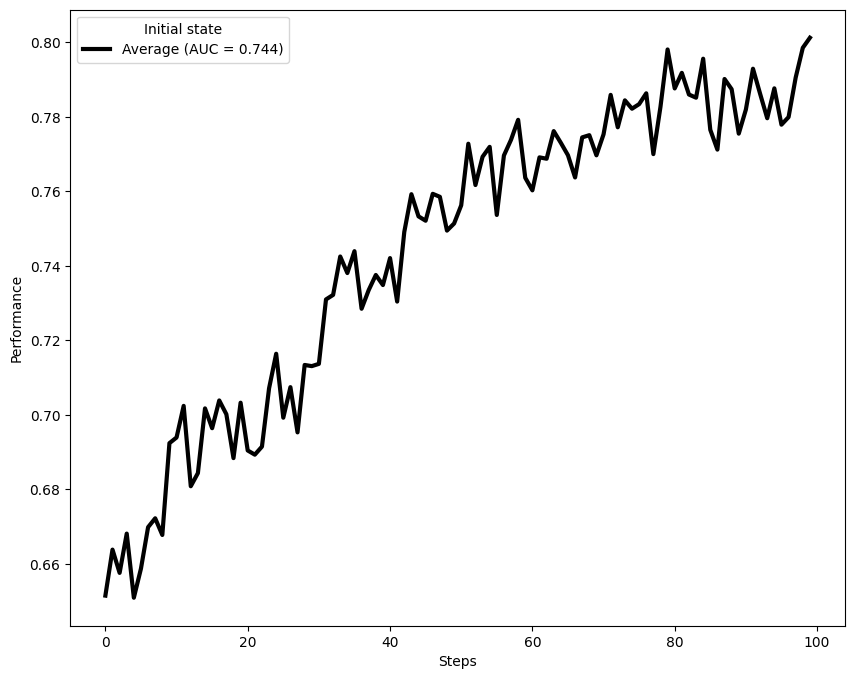

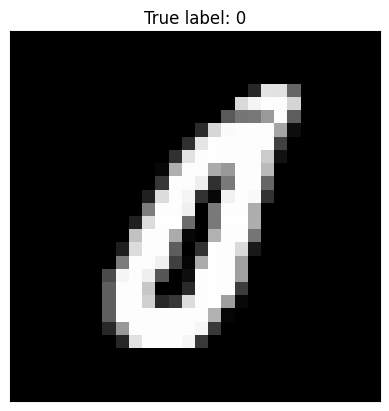

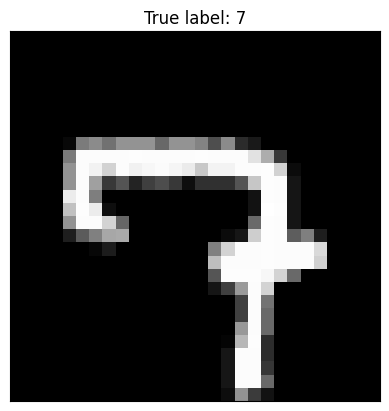

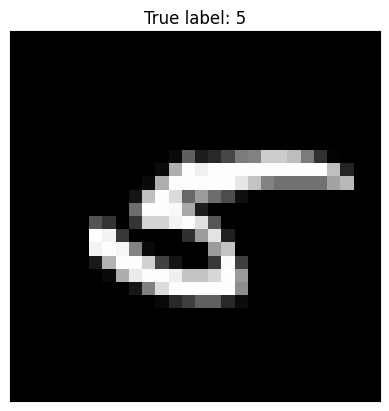

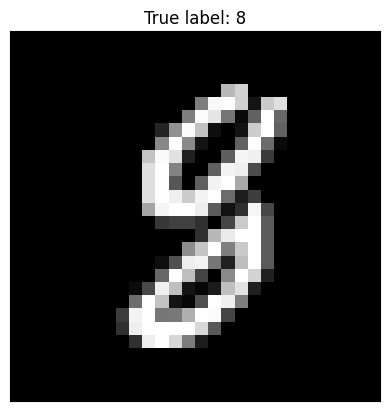

In [42]:
plot_all_results(np.array([results]))

for i in range(0, 100, 30):
    display(selected_idx[i], True)

### Embed samples into 2d using UMAP 

Implement a function that embeds all samples into 2d space using `umap-learn` library - https://umap-learn.readthedocs.io/en/latest/.

If it is too slow, think how to speed it up. Subsampling or 

In [ ]:
# write your code here
import umap
import numpy as np

def embed_umap_2d(X, n_neighbors=15, min_dist=0.1):

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2
    )
    
    embedding = reducer.fit_transform(X)
    return embedding, reducer

size_to_classify = X.size
print("Step 1")
embedded_2D_X, reducer_X = embed_umap_2d(X[:size_to_classify])
print("Step 2")



C:\Users\elg23\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 1
Step 2


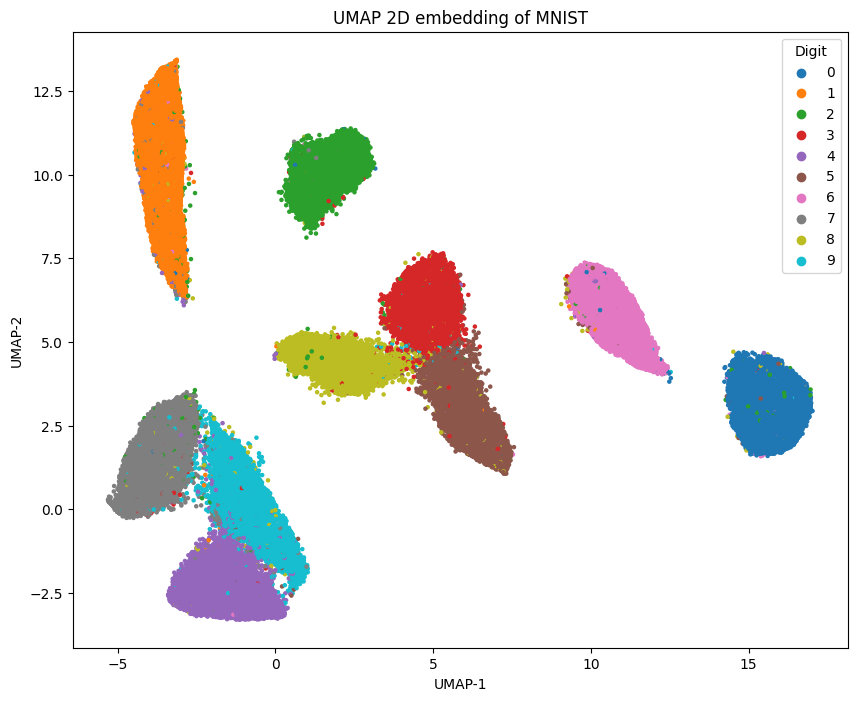

In [46]:
y = np.astype(y, int)

plt.figure(figsize=(10, 8))

plt.scatter(embedded_2D_X[:, 0], embedded_2D_X[:, 1], c=y[:size_to_classify], cmap="tab10", s=5)

# poprawiona legenda
for digit in np.unique(y[:size_to_classify]):
    plt.scatter([], [], color=plt.cm.tab10(digit), label=str(digit))

plt.legend(title="Digit")
plt.title("UMAP 2D embedding of MNIST")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()



### Visualize the labeling process

Prepare an animation (e.g., using matplotlib.animation, Plotly, or Bokeh) that will show the samples (using 2D UMAP embedding coordinates) selected in consecutive iterations. 

#### What to show in each frame:

All pool samples as a scatter plot (UMAP x/y coordinates)

Three visual states distinguished by color: not yet selected (background), selected in previous iterations, and selected in this iteration (should stand out)

Ground truth classes distinguished by marker shape (one shape per digit)

#### What to look for once it works:
This is not a gimmick — it is a diagnostic tool. Watch your animation and ask yourself:

Does entropy sampling keep picking from the same tight cluster? That suggests the model is stuck on a local decision boundary.

Does diversity sampling scatter points uniformly while ignoring boundary regions? That means you're wasting labeling budget on easy samples.

Do early iterations cover all classes, or is one digit completely ignored? That's the cold-start problem in action.

If your learning curve looks wrong but you can't figure out why, this animation is where you'll find the answer.

#### Technical hints:

matplotlib.animation.FuncAnimation is the simplest path; Plotly and Bokeh also work.

Precompute which indices belong to which state before the animation loop — don't recompute inside every frame.

Draw layers back-to-front: unselected first (low alpha), then previously selected, then current selection on top.

Use anim.to_jshtml() to get an interactive player with frame scrubbing in the notebook.

With 42k+ points and 100 frames, rendering can be slow — consider subsampling the unselected background points, or animating every 5th iteration.

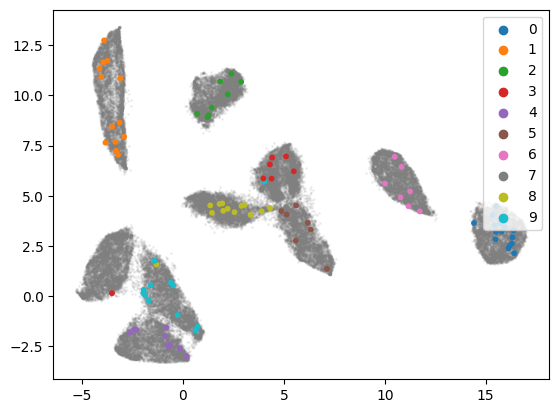

In [66]:
# write your code here
import matplotlib.animation as animation

#samples_labeled = X[selected_idx]
embedded_labeled = embedded_2D_X[selected_idx]
embedded_init = embedded_2D_X[init_idx]
y_labeled = y[selected_idx]
y_init = y[init_idx]

######################

fig, ax = plt.subplots()

# tło
bgr = ax.scatter(
    embedded_2D_X[:, 0], embedded_2D_X[:, 1],
    color="gray", alpha=0.1, s=1
)

# punkty inicjalne
init = ax.scatter(
    embedded_init[:, 0], embedded_init[:, 1],
    c=y_init, cmap="tab10", alpha=1, s=10
)

# scatter dla nowych punktów – startuje z jednym punktem
new = ax.scatter(
    [embedded_labeled[0, 0]],
    [embedded_labeled[0, 1]],
    c=[plt.cm.tab10(y_labeled[0])],   # UWAGA: bezpośredni kolor RGBA
    alpha=1,
    s=30
)

# legenda
for digit in np.unique(y):
    ax.scatter([], [], color=plt.cm.tab10(digit), label=str(digit))

ax.legend()


def update(frame):
    # współrzędne nowych punktów
    new.set_offsets(embedded_labeled[:frame])

    # kolory nowych punktów — bezpośrednie RGBA
    colors = plt.cm.tab10(y_labeled[:frame])
    new.set_facecolors(colors)

    return (new,)


ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=len(embedded_labeled),
    interval=200
)

ani.save("Lab04_animation.gif", writer="pillow")
